正在生成雷达二维回波矩阵....
步骤1：正在进行快时间FFT....
步骤2：正在进行Keystone变换重采样....
步骤3 & 4：正在进行距离向脉冲压缩与IFFT回归时域....
正在绘制结果矩阵...


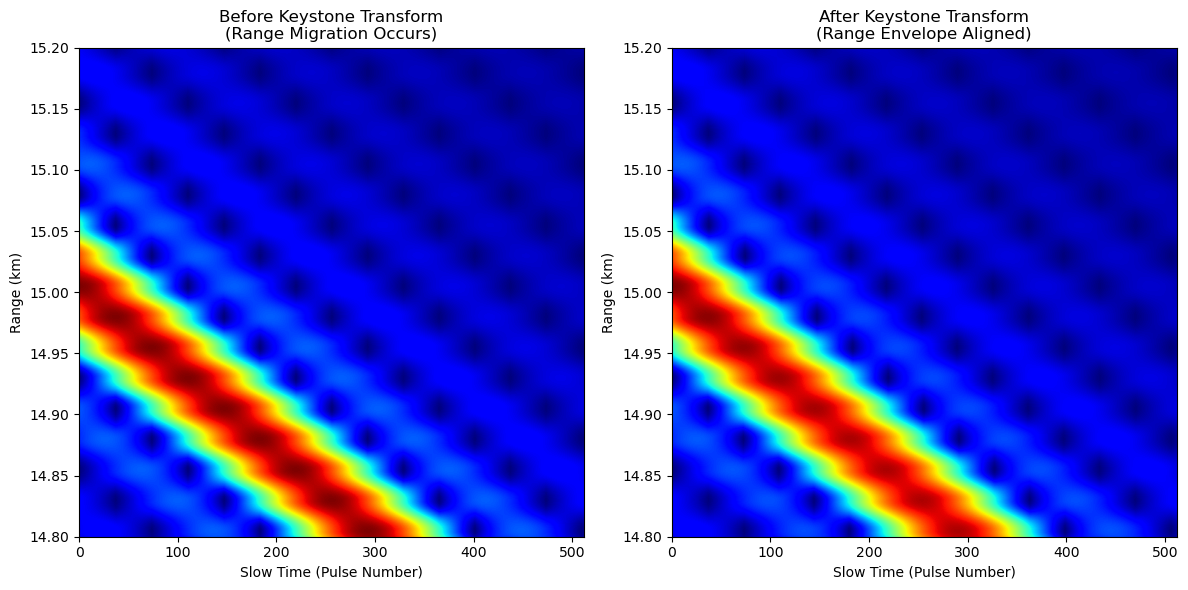

In [8]:
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt

# 1.雷达与目标参数设置
# ============================
fc = 3e9             # 雷达工作频率 (Hz)
c = 3e8              # 光速 (m/s)
B = 2e6              # 信号带宽 (Hz)
Tp = 0.1e-3          # 脉冲宽度 (s)
gamma = B / Tp       # 调频率 (Hz/s)
fs = 6e6             # 采样率 (Hz)
PRF = 1e3            # 脉冲重复频率 (Hz)
M = 512              # CPI内的脉冲数
Tr = 1 / PRF         # 脉冲重复周期 (s)

# 目标参数
R0 = 15000              # 目标初始距离 (m)
v = 680                 # 目标径向速度 (m/s)
a = 30                  # 目标径向加速度 (m/s^2)

# 2.生成二维时间矩阵
# ============================
N = 2048             # 每个脉冲的采样点数
t_fast = np.arange(N) / fs # 快时间向量
t_slow = np.arange(M) * Tr  # 慢时间向量

# 3.模拟雷达原始回波生成 S（t，tm）
# ============================
print("正在生成雷达二维回波矩阵....")
echo_matrix = np.zeros((N,M),dtype=complex)  # 初始化回波矩阵

for m in range(M):
    tm = t_slow[m]  # 当前脉冲的慢时间
    R_tm = R0 - v * tm - 0.5 * a * tm**2      # 目标的瞬时距离（假设朝向雷达运动）
    tau_delay = 2 * R_tm / c                      # 往返时间延迟
    # 构建快时间信号
    t_minus_tau = t_fast - tau_delay

    # 矩形窗包络
    rect_window = (t_minus_tau >= -Tp/2) & (t_minus_tau <= Tp/2)

    # Chirp回波信号与多普勒相位  
    phase_chirp = -np.pi * gamma * (t_minus_tau)**2
    phase_doppler = -4 * np.pi * fc * R_tm / c

    echo_matrix[:,m] = rect_window * np.exp(1j * phase_chirp) *np.exp(1j * phase_doppler)

# 4.算法核心步骤 1：快时间FFT
print("步骤1：正在进行快时间FFT....")

S_f_tm = np.fft.fft(echo_matrix, axis=0)  # 对每个慢时间点进行快时间FFT
freq_fast = np.fft.fftfreq(N, d=1/fs)  # 快时间频率轴

# 5.算法核心步骤 2：Keystone 变换重采样
print("步骤2：正在进行Keystone变换重采样....")
S_f_tau = np.zeros_like(S_f_tm)  # 初始化重采样后的矩阵

for i in range(N):
    f_i = freq_fast[i]
    alpha = fc / (f_i + fc)  # Keystone变换的缩放因子
    query_points = t_slow * alpha  # 慢时间重采样点

    # Chirp-Z变换实现重采样
    interpolator = interp1d(t_slow, S_f_tm[i, :], kind='linear', fill_value='extrapolate')
    S_f_tau[i, :] = interpolator(query_points)

# 6.算法核心步骤 3 & 4：距离向脉冲压缩与IFFT回归时域
print("步骤3 & 4：正在进行距离向脉冲压缩与IFFT回归时域....")
# 距离向匹配滤波器 H(f,tau) = exp(-j * pi * f^2 / gamma)
H_match = np.exp(-1j * np.pi * (freq_fast**2) / gamma)  # 匹配滤波器
H_match_2D = np.tile(H_match[:, np.newaxis], (1, M))  # 扩展到二维


# --- 对比组：对未进行 KT 直接脉冲压缩 ---
S_comp_before_KT = S_f_tm * H_match_2D  # 直接匹配滤波
s_comp_before_KT = np.fft.ifft(S_comp_before_KT, axis=0)  # IFFT回时域

# --- KT组：对经过 KT 重采样后的数据进行脉冲压缩 ---
S_comp_after_KT = S_f_tau * H_match_2D
s_comp_after_KT = np.fft.ifft(S_comp_after_KT, axis=0)


# 7.可视化结果对比
print("正在绘制结果矩阵...")
# 计算真实的距离轴 (km)
range_axis = t_fast * c / 2 / 1000 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# 绘制未作 KT 的矩阵 (目标轨迹是一条斜线)
ax1.imshow(np.abs(s_comp_before_KT), aspect='auto', origin='lower', 
           extent=[0, M, range_axis[0], range_axis[-1]], cmap='jet')
ax1.set_title('Before Keystone Transform\n(Range Migration Occurs)')
ax1.set_xlabel('Slow Time (Pulse Number)')
ax1.set_ylabel('Range (km)')
ax1.set_ylim(14.8, 15.2) # 放大目标所在区域

# 绘制作了 KT 的矩阵 (目标轨迹被拉直)
ax2.imshow(np.abs(s_comp_after_KT), aspect='auto', origin='lower', 
           extent=[0, M, range_axis[0], range_axis[-1]], cmap='jet')
ax2.set_title('After Keystone Transform\n(Range Envelope Aligned)')
ax2.set_xlabel('Slow Time (Pulse Number)')
ax2.set_ylabel('Range (km)')
ax2.set_ylim(14.8, 15.2) # 放大目标所在区域

plt.tight_layout()
plt.show()

正在生成雷达二维回波矩阵...
步骤 1: 执行快时间 FFT...
步骤 2: 执行 Keystone 变换重采样 (探测到多普勒折叠次数 F=14.0)...
步骤 3 & 4: 距离向脉冲压缩与 IFFT 回归时域...
正在绘制结果矩阵...


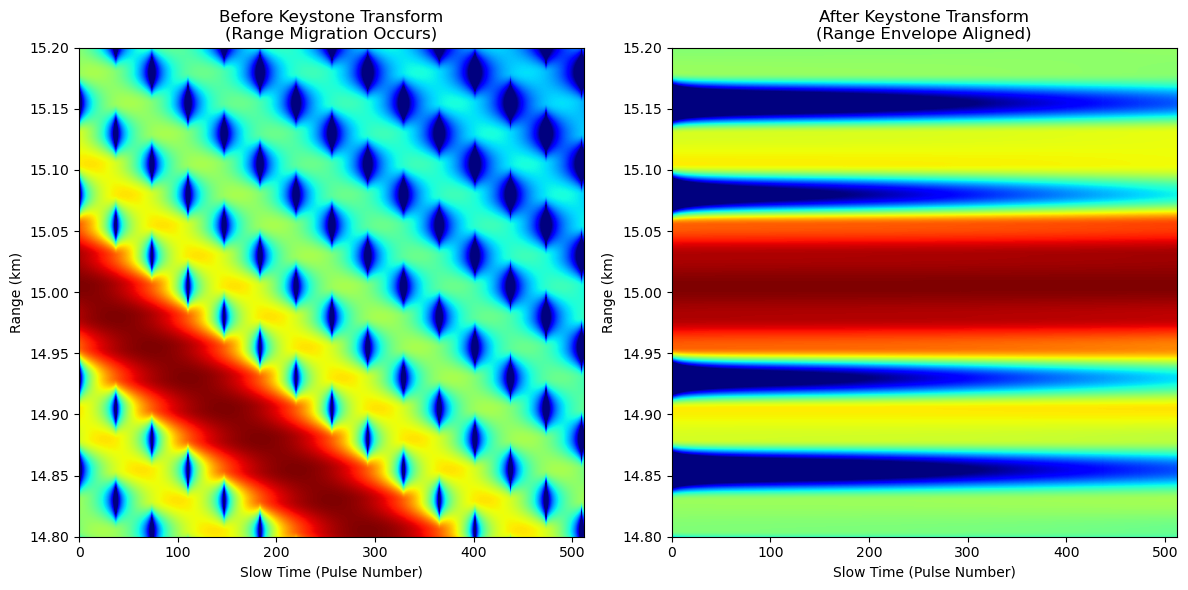

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# ==========================================
# 1. 雷达与目标参数设置
# ==========================================
fc = 3e9         
c = 3e8          
B = 2e6          
Tp = 0.1e-3      
gamma = B / Tp   
fs = 6e6         
PRF = 1000       
M = 512          
Tr = 1 / PRF     

R0 = 15000       
v = 680          
a = 30           

# ==========================================
# 2. 生成二维时间轴矩阵
# ==========================================
N = 2048 
t_fast = np.arange(N) / fs
t_slow = np.arange(M) * Tr

# ==========================================
# 3. 模拟雷达原始回波
# ==========================================
print("正在生成雷达二维回波矩阵...")
echo_matrix = np.zeros((N, M), dtype=complex)

for m in range(M):
    tm = t_slow[m]
    R_tm = R0 - v * tm - 0.5 * a * tm**2
    tau_delay = 2 * R_tm / c
    t_minus_tau = t_fast - tau_delay
    
    rect_window = (t_minus_tau >= -Tp/2) & (t_minus_tau <= Tp/2)
    phase_chirp = -np.pi * gamma * (t_minus_tau)**2
    phase_doppler = -4 * np.pi * fc * R_tm / c
    
    echo_matrix[:, m] = rect_window * np.exp(1j * phase_chirp) * np.exp(1j * phase_doppler)

# ==========================================
# 4. 快时间 FFT
# ==========================================
print("步骤 1: 执行快时间 FFT...")
S_f_tm = np.fft.fft(echo_matrix, axis=0)
freq_fast = np.fft.fftfreq(N, d=1/fs)

# ----------------- 核心修复区 -----------------
# 计算多普勒折叠因子 (Fold Factor)
fd_true = 2 * v / (c / fc)
F = np.round(fd_true / PRF) # 计算折叠次数
# ----------------------------------------------

# ==========================================
# 5. Keystone 变换 (带折叠补偿)
# ==========================================
print(f"步骤 2: 执行 Keystone 变换重采样 (探测到多普勒折叠次数 F={F})...")
S_f_tau = np.zeros_like(S_f_tm)

for i in range(N):
    f_i = freq_fast[i]
    alpha = fc / (f_i + fc)
    query_points = alpha * t_slow
    
    interpolator = interp1d(t_slow, S_f_tm[i, :], kind='cubic', fill_value='extrapolate')
    
    # 论文公式(19)推导出的折叠相位补偿项
    fold_correction = np.exp(1j * 2 * np.pi * F * np.arange(M) * alpha)
    
    # 插值后强制补回丢失的相位周期！
    S_f_tau[i, :] = interpolator(query_points) * fold_correction

# ==========================================
# 6. 脉冲压缩与 IFFT
# ==========================================
print("步骤 3 & 4: 距离向脉冲压缩与 IFFT 回归时域...")
# 修复：匹配滤波器必须是共轭的（带有负号）
H_match = np.exp(-1j * np.pi * (freq_fast**2) / gamma)
H_match_2D = np.tile(H_match[:, np.newaxis], (1, M))

# ---- 对比组: 未进行 KT ----
S_comp_before_KT = S_f_tm * H_match_2D
s_comp_before_KT = np.fft.ifft(S_comp_before_KT, axis=0)

# ---- 实验组: 进行 KT ----
S_comp_after_KT = S_f_tau * H_match_2D
s_comp_after_KT = np.fft.ifft(S_comp_after_KT, axis=0)

# ==========================================
# 7. 可视化结果对比 (引入 dB 显示)
# ==========================================
print("正在绘制结果矩阵...")
range_axis = t_fast * c / 2 / 1000 

# 计算 dB 值，方便看清尖锐的脉冲峰值
db_before = 20 * np.log10(np.abs(s_comp_before_KT) + 1e-10)
db_after = 20 * np.log10(np.abs(s_comp_after_KT) + 1e-10)
vmax = np.max(db_after)
vmin = vmax - 40 # 动态范围设置为 40dB

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.imshow(db_before, aspect='auto', origin='lower', 
           extent=[0, M, range_axis[0], range_axis[-1]], cmap='jet', vmin=vmin, vmax=vmax)
ax1.set_title('Before Keystone Transform\n(Range Migration Occurs)')
ax1.set_xlabel('Slow Time (Pulse Number)')
ax1.set_ylabel('Range (km)')
ax1.set_ylim(14.8, 15.2)

ax2.imshow(db_after, aspect='auto', origin='lower', 
           extent=[0, M, range_axis[0], range_axis[-1]], cmap='jet', vmin=vmin, vmax=vmax)
ax2.set_title('After Keystone Transform\n(Range Envelope Aligned)')
ax2.set_xlabel('Slow Time (Pulse Number)')
ax2.set_ylabel('Range (km)')
ax2.set_ylim(14.8, 15.2)

plt.tight_layout()
plt.show()